# 02 – Feature Engineering
**Project**: Spotify Music Recommender & Analysis  
**Author**: S33mi  
**Goal**: Prepare a clean, scaled feature matrix ready for content-based recommendation and clustering.

This notebook builds directly on the cleaned data from `01_data_collection_eda.ipynb`.


## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.decomposition import PCA
import joblib
import warnings
import kagglehub #for dataset

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option("display.max_columns", 50)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Load Cleaned Data

Make sure you have already run notebook 01 and saved the cleaned dataset  
(or simply re-load and apply the same cleaning steps).


In [2]:

#DATA_PATH = "data/dataset.csv"          # original file
# If you saved a cleaned version in notebook 01, use that path instead:
# DATA_PATH = "data/cleaned_spotify.csv"

#df = pd.read_csv(DATA_PATH)
#----------------------------

path = kagglehub.dataset_download("maharshipandya/-spotify-tracks-dataset")
df = pd.read_csv(f"{path}/dataset.csv")   # ← change filename if different


# ---------- Same cleaning steps as notebook 01 ----------
df = df.drop_duplicates(subset=["track_id"]).reset_index(drop=True)

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

df["duration_min"] = df["duration_ms"] / 60000

print(f"Loaded data shape: {df.shape}")
df.head()

Using Colab cache for faster access to the '-spotify-tracks-dataset' dataset.
Loaded data shape: (89741, 21)


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,3.844433
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,2.493500
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,3.513767
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,3.365550
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,3.314217


## 3. Select Features for the Recommender

We focus on the core audio features that describe the *sound* of a track.  
These will form the basis of content-based similarity.

In [3]:
# Core numerical features for silarity
feature_cols = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_min"          # using minutes instead of ms
]

# Optional: include popularity if you want it in the feature space
# feature_cols.append("popularity")

# Keep metadata for later (recommendations, display, etc.)
meta_cols = [
    "track_id",
    "track_name",
    "artists",
    "album_name",
    "track_genre",
    "popularity"
]

# Create working dataframes
features_df = df[feature_cols].copy()
meta_df = df[meta_cols].copy()

print("Selected feature columns:")
print(feature_cols)
print(f"\nFeature matrix shape: {features_df.shape}")

Selected feature columns:
['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_min']

Feature matrix shape: (89741, 10)


### Quick check for missing values in features


In [4]:
print("Missing values in feature columns:")
print(features_df.isnull().sum())

# If any missing values exist, fill with median (rare in this dataset)
features_df = features_df.fillna(features_df.median())

Missing values in feature columns:
danceability        0
energy              0
loudness            0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
duration_min        0
dtype: int64



## 4. Feature Scaling

Audio features have different scales (e.g. loudness is in dB, tempo in BPM, others 0-1).  
We need to scale them before computing distances / similarity.


In [5]:
# We will try two common scalers and keep the StandardScaler version as primary

scaler_standard = StandardScaler()
scaler_minmax = MinMaxScaler()

features_scaled_std = scaler_standard.fit_transform(features_df)
features_scaled_mm = scaler_minmax.fit_transform(features_df)

# Convert back to DataFrames for convenience
features_std_df = pd.DataFrame(features_scaled_std, columns=feature_cols)
features_mm_df = pd.DataFrame(features_scaled_mm, columns=feature_cols)

print("StandardScaler – mean & std of scaled features:")
print(features_std_df.agg(["mean", "std"]).round(4))

StandardScaler – mean & std of scaled features:
      danceability  energy  loudness  speechiness  acousticness  \
mean          -0.0     0.0      -0.0          0.0          -0.0   
std            1.0     1.0       1.0          1.0           1.0   

      instrumentalness  liveness  valence  tempo  duration_min  
mean              -0.0       0.0     -0.0   -0.0          -0.0  
std                1.0       1.0      1.0    1.0           1.0  


### Visual comparison of scaling

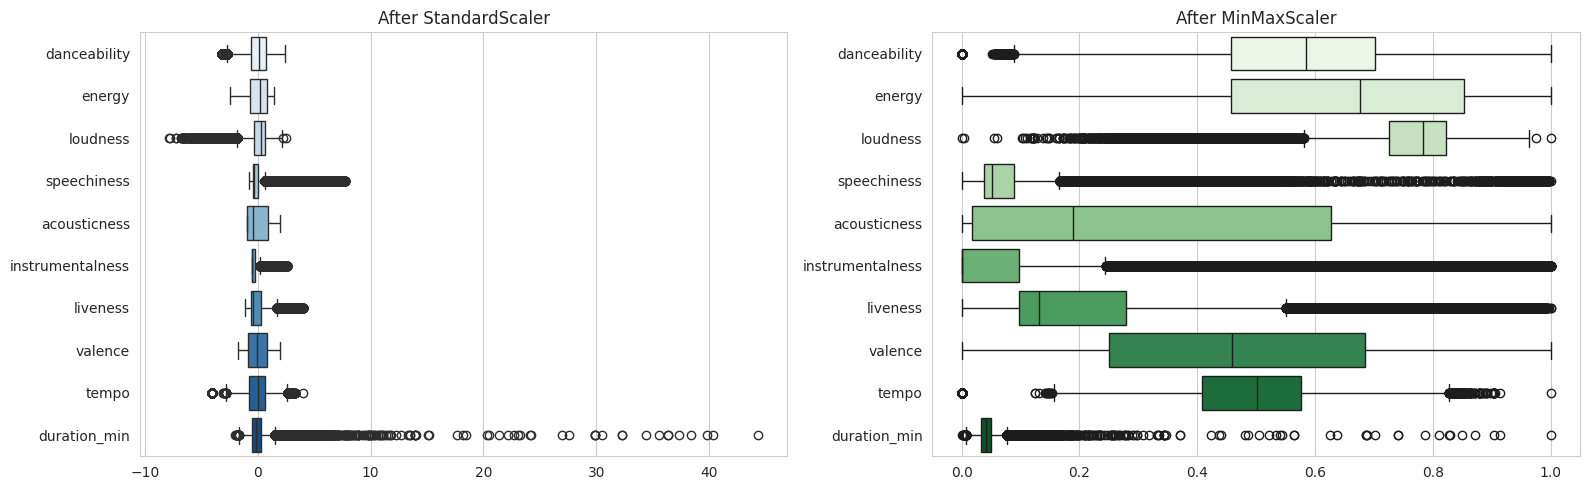

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(data=features_std_df, ax=axes[0], orient="h", palette="Blues")
axes[0].set_title("After StandardScaler")

sns.boxplot(data=features_mm_df, ax=axes[1], orient="h", palette="Greens")
axes[1].set_title("After MinMaxScaler")

plt.tight_layout()
plt.show()



**Decision**: We will use **StandardScaler** as the primary scaling method  
(better for distance-based methods like cosine similarity and KNN when features are roughly Gaussian).

## 5. Optional: Dimensionality Reduction Preview (PCA)



Original features : 10
PCA components    : 8
Explained variance: 0.953


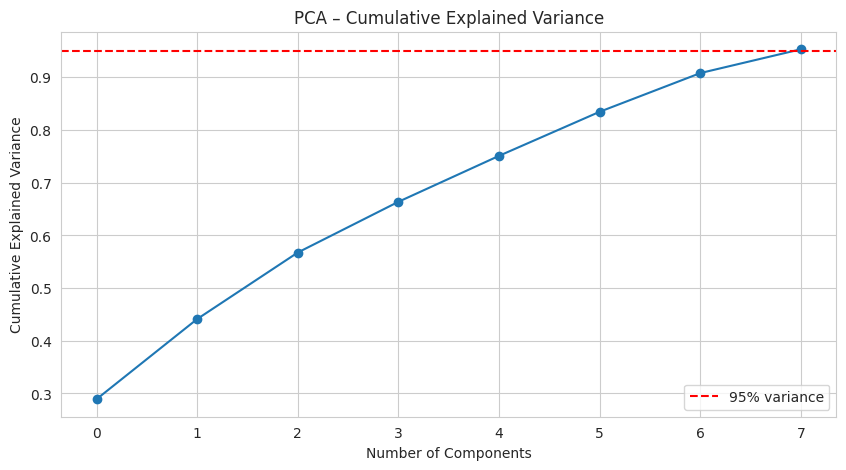

In [7]:
pca = PCA(n_components=0.95, random_state=42)   # keep 95% variance
pca_features = pca.fit_transform(features_scaled_std)

print(f"Original features : {features_scaled_std.shape[1]}")
print(f"PCA components    : {pca_features.shape[1]}")
print(f"Explained variance: {pca.explained_variance_ratio_.sum():.3f}")

# Cumulative variance plot
plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker="o")
plt.axhline(0.95, color="red", linestyle="--", label="95% variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA – Cumulative Explained Variance")
plt.legend()
plt.grid(True)
plt.show()


PCA is useful for visualization and can be used later if we want a lower-dimensional representation.  
For the main recommender we will keep the full scaled feature set.

## 6. Create Final Feature Matrix + Metadata

In [8]:
# Final scaled feature matrix (StandardScaler)
X = features_std_df.copy()

# Combine with metadata for easy lookup later
final_df = pd.concat([meta_df.reset_index(drop=True), X], axis=1)

print("Final combined dataframe shape:", final_df.shape)
final_df.head()

Final combined dataframe shape: (89741, 16)


,track_id,track_name,artists,album_name,track_genre,popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_min
0,5SuOikwiRyPMVoIQDJUgSV,Comedy,Gen Hoshino,Comedy,acoustic,73,0.644260,-0.675976,0.335731,0.490464,-0.875177,-0.535478,0.723666,0.934036,-1.133609,0.013495
1,4qPNDBW1i3p13qLCt0Ki3A,Ghost - Acoustic,Ben Woodward,Ghost (Acoustic),acoustic,55,-0.804604,-1.825609,-1.673094,-0.098361,1.760797,-0.535464,-0.595072,-0.770280,-1.479854,-0.704151
2,1iJBSr7s7jYXzM8EGcbK5b,To Begin Again,Ingrid Michaelson;ZAYN,To Begin Again,acoustic,57,-0.702731,-1.073476,-0.236523,-0.280217,-0.349638,-0.535481,-0.512971,-1.329508,-1.518271,-0.162163
3,6lfxq3CG4xtTiEg7opyCyx,Can't Help Falling In Love,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,acoustic,71,-1.676186,-2.240257,-1.918236,-0.451480,1.704637,-0.535263,-0.436002,-1.242010,1.981637,-0.240899
4,5vjLSffimiIP26QG5WcN2K,Hold On,Chord Overstreet,Hold On,acoustic,82,0.316001,-0.746123,-0.226373,-0.307584,0.415912,-0.535481,-0.687948,-1.150708,-0.070037,-0.268168



## 7. Save Artifacts for Next Notebooks


In [9]:

import os
os.makedirs("data/processed", exist_ok=True)
os.makedirs("models", exist_ok=True)

# Save the scaled feature matrix + metadata
final_df.to_csv("data/processed/spotify_features_scaled.csv", index=False)

# Save only the pure feature matrix (numpy) for fast loading in recommender
np.save("data/processed/X_scaled.npy", X.values)

# Save the scaler so we can transform new songs later
joblib.dump(scaler_standard, "models/standard_scaler.pkl")

# Save the list of feature columns
joblib.dump(feature_cols, "models/feature_columns.pkl")

print("Artifacts saved:")
print("  - data/processed/spotify_features_scaled.csv")
print("  - data/processed/X_scaled.npy")
print("  - models/standard_scaler.pkl")
print("  - models/feature_columns.pkl")

Artifacts saved:
  - data/processed/spotify_features_scaled.csv
  - data/processed/X_scaled.npy
  - models/standard_scaler.pkl
  - models/feature_columns.pkl


## 8. Quick Sanity Check

In [10]:
print("Feature matrix statistics (after StandardScaler):")
display(X.describe().round(3))

print("\nSample of final dataframe:")
display(final_df[["track_name", "artists", "track_genre", "popularity"] + feature_cols].head())

Feature matrix statistics (after StandardScaler):


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_min
count,89741.000,89741.000,89741.000,89741.000,89741.000,89741.000,89741.000,89741.000,89741.000,89741.000
mean,-0.000,0.000,-0.000,0.000,-0.000,-0.000,0.000,-0.000,-0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-3.182,-2.473,-7.858,-0.772,-0.970,-0.535,-1.113,-1.786,-4.053,-2.029
25%,-0.635,-0.692,-0.349,-0.454,-0.920,-0.535,-0.609,-0.839,-0.757,-0.497
50%,0.078,0.162,0.252,-0.340,-0.415,-0.535,-0.436,-0.047,-0.002,-0.140
75%,0.735,0.852,0.649,-0.014,0.877,-0.234,0.318,0.808,0.598,0.311
max,2.393,1.425,2.496,7.747,1.974,2.552,4.018,1.999,4.028,44.341



Sample of final dataframe:


,track_name,artists,track_genre,popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_min
0,Comedy,Gen Hoshino,acoustic,73,0.644260,-0.675976,0.335731,0.490464,-0.875177,-0.535478,0.723666,0.934036,-1.133609,0.013495
1,Ghost - Acoustic,Ben Woodward,acoustic,55,-0.804604,-1.825609,-1.673094,-0.098361,1.760797,-0.535464,-0.595072,-0.770280,-1.479854,-0.704151
2,To Begin Again,Ingrid Michaelson;ZAYN,acoustic,57,-0.702731,-1.073476,-0.236523,-0.280217,-0.349638,-0.535481,-0.512971,-1.329508,-1.518271,-0.162163
3,Can't Help Falling In Love,Kina Grannis,acoustic,71,-1.676186,-2.240257,-1.918236,-0.451480,1.704637,-0.535263,-0.436002,-1.242010,1.981637,-0.240899
4,Hold On,Chord Overstreet,acoustic,82,0.316001,-0.746123,-0.226373,-0.307584,0.415912,-0.535481,-0.687948,-1.150708,-0.070037,-0.268168



## Summary

- Selected 10 core audio features  
- Applied **StandardScaler**  
- Optional PCA analysis performed  
- Saved:
  - Scaled feature matrix + metadata
  - Pure numpy feature matrix
  - Fitted scaler & feature column list

**Next notebook**: `03_recommender.ipynb`  
→ Build content-based recommender using cosine similarity / KNN on the scaled features.